<a href="https://colab.research.google.com/github/chavezgranados/Quantitative-Methods/blob/main/notebooks/cuaderno8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">

<font face="gotham" color="#1B5E20"> Unidad de Posgrado de la Facultad de Economía </font>

<img src="https://yachay.digital/wp-content/uploads/2021/03/uncp.png" width="120">

<font face="gotham" color="#1B5E20"> **Curso: Métodos Cuantitativos Aplicados a la Investigación** </font>

<hr width="50%" color="#C9A227">

<font face="gotham" color="#1B5E20"> Maestría en Planificación y Proyectos de Inversión </font>

<font face="gotham" color="#1B5E20"> `Luis Chávez` </font>

<font face="gotham" color="#1B5E20"> 2026 </font>

# <font face="gotham" color="#E3B10D"> **Tópico: introducción a minería de datos**

In [2]:
# Preámbulo ====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

## **1. Clustering**

In [3]:
url = "https://raw.githubusercontent.com/chavezgranados/Quantitative-Methods/main/datasets/01clientes.xlsx"
datos = pd.read_excel(url)
datos.head()

,fecha,NumeroOperacion,CodigoCliente,Estado,Riesgo,Agencia_Venta,Plazo_Dias,Tasa_Interes,Saldo_Prom_Periodo,Saldo_Corte,...,Transferencia,Provision_Req,Provision,Dealers,Gastos_Inversion,Gastos_Indirectos,Transferencia_Total,Desembolso_Neto,EstadoCivil,Sexo
0,2023-01-31,1,1,Vigentes,BAJO,AG. CHIMBOTE,2227,10.6,13661.19,16000.00,...,-111.503534,71.32,160.00,0.0,1.934347,51.852710,-110.197603,7220.21,1,0
1,2023-02-28,1,1,Vigentes,BAJO,AG. CHIMBOTE,2227,10.6,16000.00,16000.00,...,-117.910000,0.00,160.00,0.0,0.916893,7.958110,-116.730925,0.00,1,1
2,2023-03-31,1,1,Vigentes,BAJO,AG. CHIMBOTE,2227,10.6,15869.68,15844.62,...,-129.530000,-1.55,158.45,0.0,0.597064,7.648716,-128.236721,0.00,2,0
3,2023-04-30,1,1,Vigentes,MUY BAJO,AG. CHIMBOTE,2227,10.6,15710.42,15689.77,...,-124.080000,-1.55,156.90,0.0,2.269683,7.675703,-122.840849,0.00,0,1
4,2023-05-31,1,1,Vigentes,MUY BAJO,AG. CHIMBOTE,2227,10.6,15564.93,15528.52,...,-127.040000,-1.61,155.29,0.0,0.911305,6.753662,-125.772513,0.00,2,1


In [4]:
datos = datos.replace("(en blanco)", np.nan)

In [5]:
datos = datos.dropna(subset=["Estado"])

In [6]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32715 entries, 0 to 38495
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   fecha                 32715 non-null  datetime64[ns]
 1   NumeroOperacion       32715 non-null  int64         
 2   CodigoCliente         32715 non-null  int64         
 3   Estado                32715 non-null  object        
 4   Riesgo                32343 non-null  object        
 5   Agencia_Venta         32678 non-null  object        
 6   Plazo_Dias            32715 non-null  int64         
 7   Tasa_Interes          32715 non-null  float64       
 8   Saldo_Prom_Periodo    32715 non-null  float64       
 9   Saldo_Corte           32715 non-null  float64       
 10  Ingresos_Financieros  32715 non-null  float64       
 11  Transferencia         32715 non-null  float64       
 12  Provision_Req         32715 non-null  float64       
 13  Provision            

### **1.1 Clustering de partición**

**K-means:**

In [7]:
clientes = (datos.groupby("CodigoCliente").agg(
          N_Creditos=("NumeroOperacion","count"),
          Saldo_Total=("Saldo_Corte","sum"),
          Saldo_Promedio=("Saldo_Corte","mean"),
          Tasa_Promedio=("Tasa_Interes","mean"),
          Plazo_Promedio=("Plazo_Dias","mean"),
          Ingreso_Total=("Ingresos_Financieros","sum"),
          Provision_Total=("Provision","mean"),
          Riesgo_Modal=("Riesgo", lambda x: x.mode().iloc[0] if len(x.mode())>0 else None),
          Agencia_Modal=("Agencia_Venta", "first"),
          EstadoCivil=("EstadoCivil","first"),
          Sexo=("Sexo","first"))
      .reset_index())

In [8]:
X = clientes.select_dtypes(include=["int64", "float64"]).drop(columns=['CodigoCliente', 'Sexo', 'EstadoCivil'])
X.head()

,N_Creditos,Saldo_Total,Saldo_Promedio,Tasa_Promedio,Plazo_Promedio,Ingreso_Total,Provision_Total
0,8,109639.92,13704.990000,10.60,2227.0,962.81,137.051250
1,19,2161594.55,113768.134211,10.90,2214.0,18228.68,4018.949474
2,31,912378.61,29431.568065,11.50,2241.0,8035.62,1142.301613
3,19,1542547.19,81186.694211,10.30,2234.0,12880.55,811.867368
4,21,868458.11,41355.148095,12.65,2223.0,8760.57,591.027143


In [9]:
# Paso 1: estandarizar variables
X_scaled = StandardScaler().fit_transform(X)

In [10]:
# Paso 2: identificar el número óptimo de clusters, método del Codo (Elbow)
inercia = []
for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=123,
        n_init=10    )
    kmeans.fit(X_scaled)
    inercia.append(kmeans.inertia_)

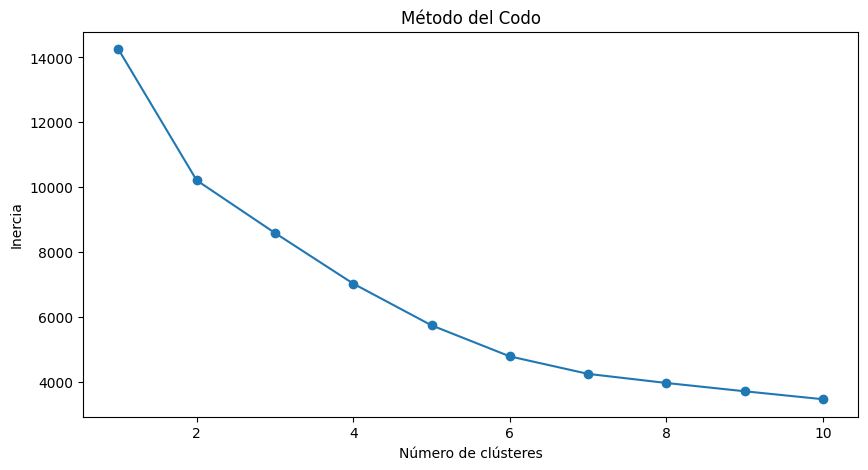

In [11]:
plt.figure(figsize=(10,5))
plt.plot(range(1,11), inercia, marker="o")
plt.xlabel("Número de clústeres")
plt.ylabel("Inercia")
plt.title("Método del Codo")
plt.show()

In [12]:
# Paso 2: identificar el número óptimo de clusters, método del Silhouette
silhouette = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=123, n_init=10)
    etiquetas = kmeans.fit_predict(X_scaled)
    silhouette.append(silhouette_score(X_scaled, etiquetas))

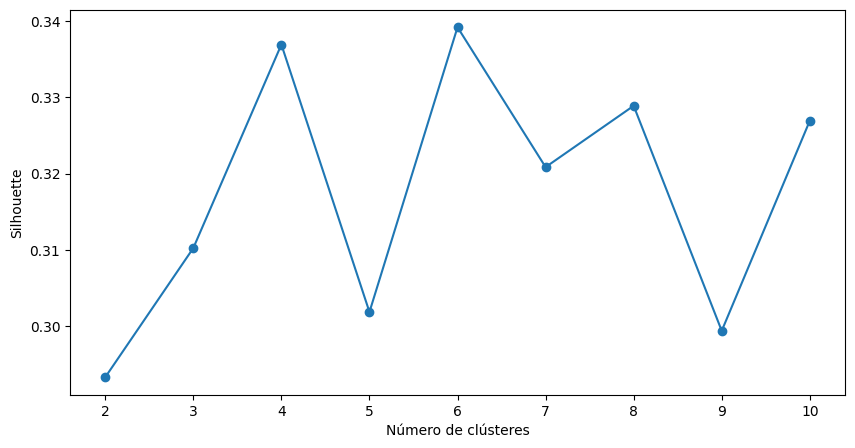

In [13]:
plt.figure(figsize=(10,5))
plt.plot(range(2,11), silhouette, marker="o")
plt.xlabel("Número de clústeres")
plt.ylabel("Silhouette")
plt.show()

In [14]:
# Paso 2: identificar el número óptimo de clusters, método de Calinski-Harabasz
calinski = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=123, n_init=10)
    etiquetas = kmeans.fit_predict(X_scaled)
    calinski.append(calinski_harabasz_score(X_scaled, etiquetas))

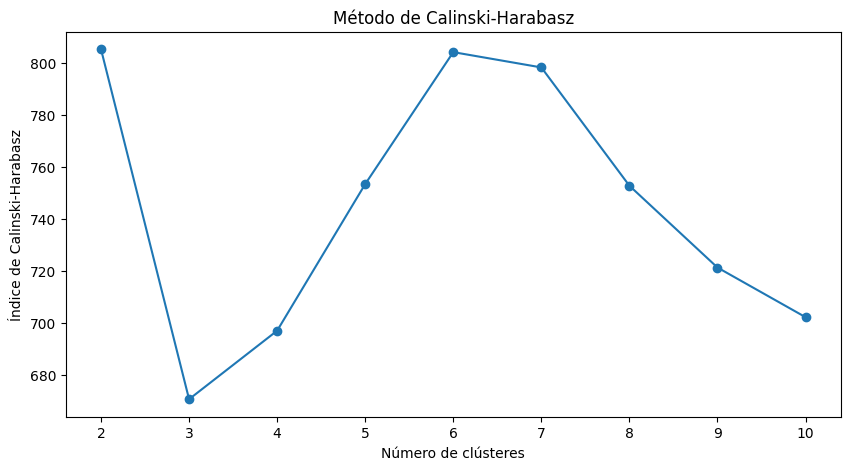

In [15]:
plt.figure(figsize=(10,5))
plt.plot(range(2,11), calinski, marker="o")
plt.xlabel("Número de clústeres")
plt.ylabel("Índice de Calinski-Harabasz")
plt.title("Método de Calinski-Harabasz")
plt.show()

**Decisión:**
K=4

In [16]:
# Paso 3: ajustar el modelo
kmeans = KMeans(n_clusters=4, random_state=123, n_init=10)
kmeans.fit(X_scaled)

KMeans(n_clusters=4, n_init=10, random_state=123)

In [17]:
clientes["Cluster"] = kmeans.labels_

In [18]:
clientes["Cluster"].value_counts()

,count
Cluster,
1,1013
3,521
0,439
2,63


In [19]:
kmeans.cluster_centers_

array([[-1.66849212, -0.95792503, -0.07164649, -0.36132476,  0.18085694,
        -0.97456415, -0.20420375],
       [ 0.4618902 ,  0.76396153,  0.58194613, -0.02508294,  0.32675075,
         0.79315847, -0.09950053],
       [ 0.63624332,  0.10905427, -0.27900722,  0.90402496,  0.68896959,
        -0.59032619,  4.82677566],
       [ 0.43082316, -0.69422753, -1.04050598,  0.24442711, -0.87332028,
        -0.65238168, -0.21836131]])

In [20]:
# Perfiles de los cluster en las variables originales
clientes.groupby("Cluster").mean(numeric_only=True).drop(columns=['CodigoCliente', 'Sexo', 'EstadoCivil'])

,N_Creditos,Saldo_Total,Saldo_Promedio,Tasa_Promedio,Plazo_Promedio,Ingreso_Total,Provision_Total
Cluster,,,,,,,
0,6.881549,3.729501e+05,52097.033698,12.000247,2154.395768,3465.545376,584.148693
1,18.615005,1.269538e+06,68653.934207,12.875678,2236.556618,12007.311027,895.789962
2,19.571429,9.281603e+05,46851.664581,15.304518,2441.762621,5321.193492,15542.218021
3,18.433781,5.104722e+05,27621.568907,13.585809,1560.182210,5025.794933,542.075785


*   Cluster 0 — Clientes pequeños y sanos.
*   Cluster 1 — Clientes premium.
*   Cluster 2 — Clientes de alto riesgo.
*   Cluster 3 — Clientes de ticket pequeño y bajo riesgo.

In [21]:
# Añadir los clusters a la base inicial
df = datos.merge(clientes[["CodigoCliente", "Cluster"]], on="CodigoCliente", how="left")

In [22]:
df

,fecha,NumeroOperacion,CodigoCliente,Estado,Riesgo,Agencia_Venta,Plazo_Dias,Tasa_Interes,Saldo_Prom_Periodo,Saldo_Corte,...,Provision_Req,Provision,Dealers,Gastos_Inversion,Gastos_Indirectos,Transferencia_Total,Desembolso_Neto,EstadoCivil,Sexo,Cluster
0,2023-01-31,1,1,Vigentes,BAJO,AG. CHIMBOTE,2227,10.60,13661.19,16000.00,...,71.32,160.00,0.000000,1.934347,51.852710,-110.197603,7220.21,1,0,0
1,2023-02-28,1,1,Vigentes,BAJO,AG. CHIMBOTE,2227,10.60,16000.00,16000.00,...,0.00,160.00,0.000000,0.916893,7.958110,-116.730925,0.00,1,1,0
2,2023-03-31,1,1,Vigentes,BAJO,AG. CHIMBOTE,2227,10.60,15869.68,15844.62,...,-1.55,158.45,0.000000,0.597064,7.648716,-128.236721,0.00,2,0,0
3,2023-04-30,1,1,Vigentes,MUY BAJO,AG. CHIMBOTE,2227,10.60,15710.42,15689.77,...,-1.55,156.90,0.000000,2.269683,7.675703,-122.840849,0.00,0,1,0
4,2023-05-31,1,1,Vigentes,MUY BAJO,AG. CHIMBOTE,2227,10.60,15564.93,15528.52,...,-1.61,155.29,0.000000,0.911305,6.753662,-125.772513,0.00,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32710,2024-03-31,2036,2036,Vigentes,BAJO,AG. CARSA HUANUCO,2235,12.08,98813.14,98298.70,...,-12.26,982.99,0.000000,0.907032,60.917240,-798.496771,0.00,3,0,1
32711,2024-04-30,2036,2036,Vigentes,BAJO,AG. HUANCAYO,2235,12.08,107000.00,107000.00,...,87.01,1070.00,-150.449483,0.912238,89.719220,-681.554044,6939.73,2,0,1
32712,2024-05-31,2036,2036,Vigentes,BAJO,OF. PRINCIPAL,2235,12.08,107000.00,107000.00,...,0.00,1070.00,0.000000,0.124627,54.021720,-776.357980,0.00,2,0,1
32713,2024-06-30,2036,2036,Vigentes,BAJO,OF. PRINCIPAL,2235,12.08,106607.12,106158.12,...,-8.42,1061.58,0.000000,0.578882,57.603060,-679.079790,0.00,1,0,1


In [23]:
# Reducir a dos componentes para graficar
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

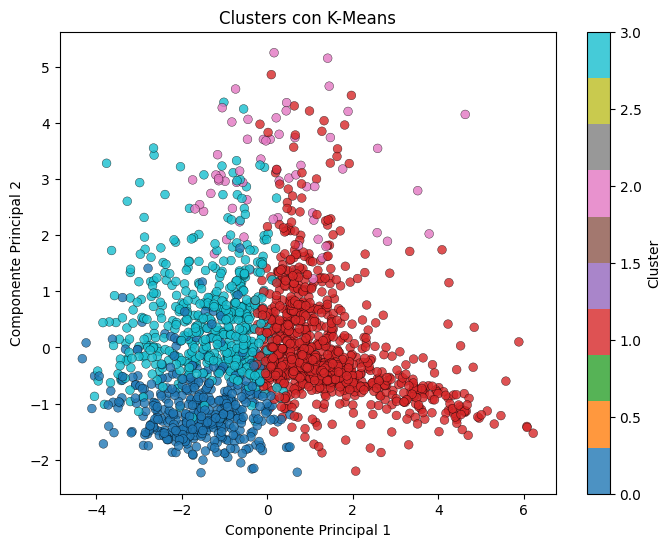

In [24]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clientes["Cluster"], cmap="tab10", s=40, alpha=0.8, edgecolors="black",
    linewidth=0.3)
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Clusters con K-Means")
plt.colorbar(label="Cluster")
plt.show()

<Axes: xlabel='Cluster'>

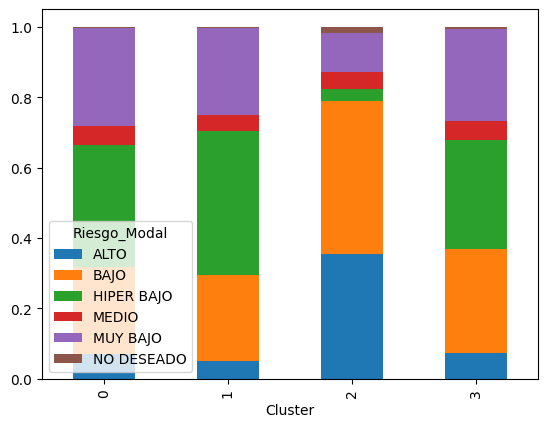

In [25]:
pd.crosstab(clientes["Cluster"], clientes["Riesgo_Modal"],
    normalize="index").plot(kind="bar", stacked=True)

### **1.2 Clustering jerárquico**

**Métodos de enlace (linkage):**
1.   Ward (funciona sólo con distancia euclidiana).
2.   complete (vecino más lejano / vinculación completa).
3.   average (vinculación promedio o intergrupos).
4.   single (vecino más cercano / vinculación simple).
5.   centroid (vinculación de centroides).

**Métrica de distancia:**
1.   Euclidiana (euclidean)
2.   Manhattan / City Block (cityblock)
3.   Coseno (cosine)
4.   Gower (para datos mixtos) # requiere pip install gower
5.   Chebyshev (chebyshev)
6.   Minkowski (minkowski)

In [26]:
# Paso 1: matriz de distancia y método de enlace (linkage)
Z = linkage(X_scaled, method='ward', metric='euclidean')

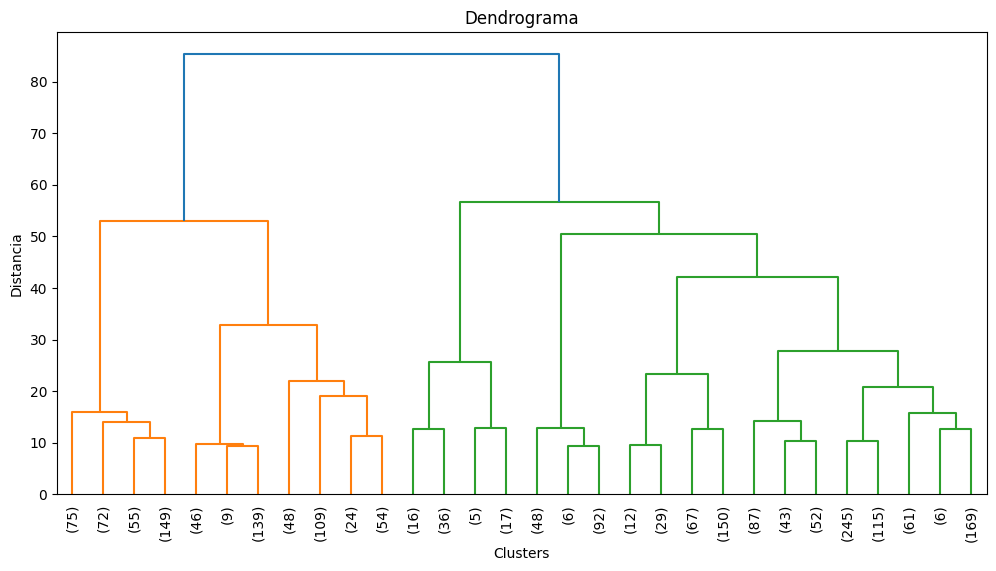

In [27]:
# Paso 2: dendograma
plt.figure(figsize=(12,6))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90, leaf_font_size=10)
plt.title("Dendrograma")
plt.xlabel("Clusters")
plt.ylabel("Distancia")
plt.show()

In [28]:
# Paso 3: ajustar el clustering
hc = AgglomerativeClustering(n_clusters=4, linkage="ward")
clientes["Cluster_HC"] = hc.fit_predict(X_scaled)

In [29]:
clientes["Cluster_HC"].value_counts().sort_index()

,count
Cluster_HC,
0,1182
1,429
2,74
3,351


In [30]:
# Paso 4: perfiles de los clustering
clientes.groupby("Cluster_HC").mean(numeric_only=True).drop(columns=['CodigoCliente', 'Sexo', 'EstadoCivil'])

,N_Creditos,Saldo_Total,Saldo_Promedio,Tasa_Promedio,Plazo_Promedio,Ingreso_Total,Provision_Total,Cluster
Cluster_HC,,,,,,,,
0,18.335025,1.195494e+06,65609.573702,12.939337,2166.750436,11326.446650,839.953180,1.190355
1,17.317016,4.139715e+05,24409.382406,13.376277,1524.147199,4062.213263,444.509648,2.657343
2,19.337838,8.920968e+05,45204.091869,15.054103,2363.722228,5635.286081,14105.579740,2.013514
3,6.219373,3.347979e+05,52399.662244,11.985296,2245.652316,3107.960798,564.460197,0.017094


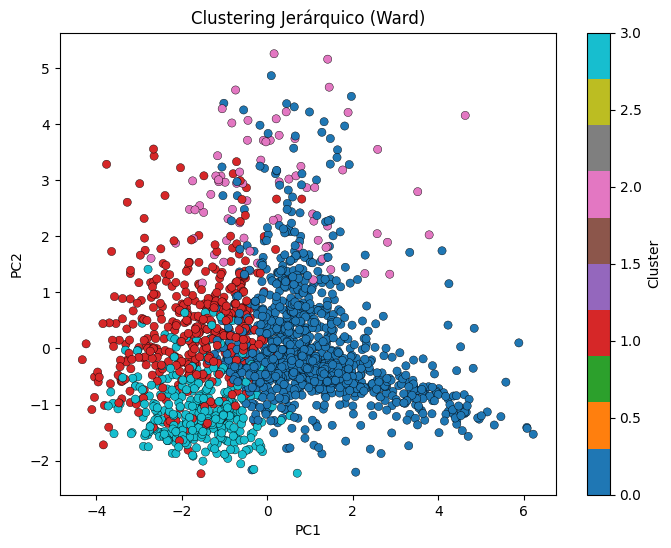

In [31]:
# Gráfico
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clientes["Cluster_HC"], cmap="tab10",
            s=35, edgecolors="black", linewidth=0.3)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clustering Jerárquico (Ward)")
plt.colorbar(label="Cluster")
plt.show()

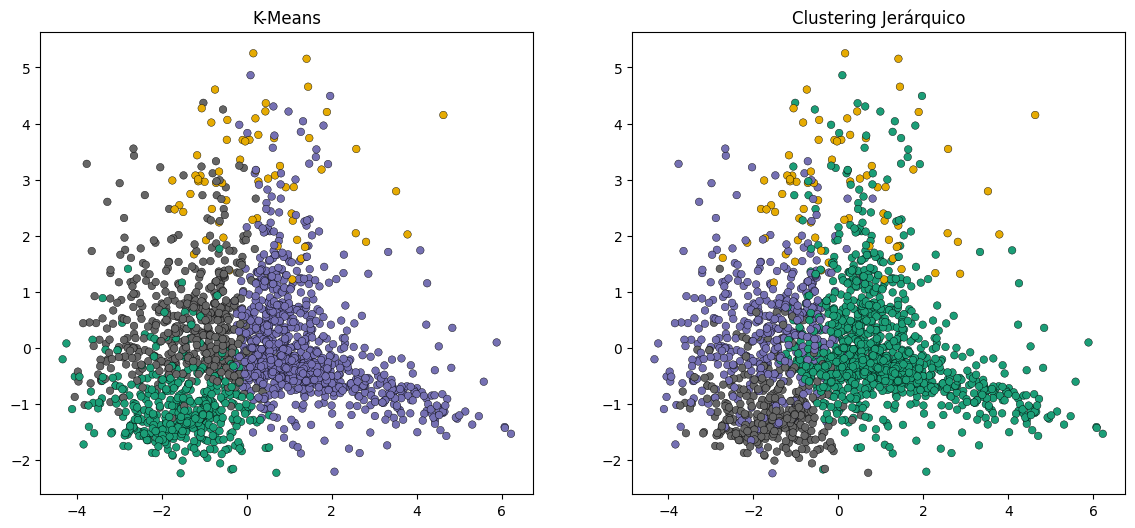

In [32]:
# Comparación
fig, ax = plt.subplots(1,2, figsize=(14,6))
# K-Means
ax[0].scatter(X_pca[:,0], X_pca[:,1], c=clientes["Cluster"], cmap="Dark2", s=30,
              edgecolors="black", linewidth=0.3)
ax[0].set_title("K-Means")
# Jerárquico
ax[1].scatter(X_pca[:,0], X_pca[:,1], c=clientes["Cluster_HC"], cmap="Dark2", s=30,
              edgecolors="black", linewidth=0.3)
ax[1].set_title("Clustering Jerárquico")
plt.show()

<Axes: xlabel='Cluster_HC'>

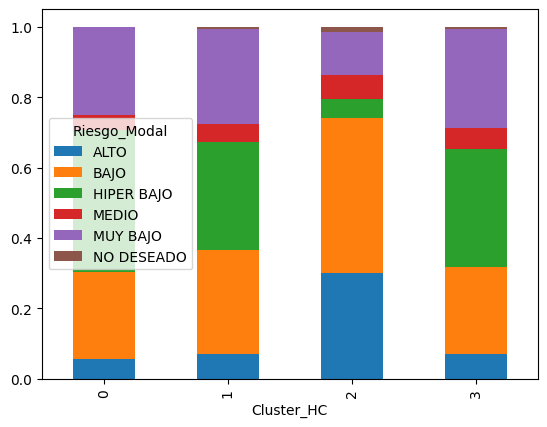

In [33]:
pd.crosstab(clientes["Cluster_HC"], clientes["Riesgo_Modal"],
    normalize="index").plot(kind="bar", stacked=True)

## **2. Clasificación**

In [34]:
#===============================================================================
# Librerías
#===============================================================================
import zipfile
import pandas as pd
import os
import numpy as np

In [35]:
pip install inei-microdatos

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 88.0 MB/s eta 0:00:00


In [36]:
import inei_microdatos

In [37]:
from inei_microdatos import load_catalog, download_modules, read_module
from inei_microdatos.catalog import filter_catalog
catalog = load_catalog()

In [38]:
enaho_2025 = filter_catalog(catalog, survey="enaho", year_min=2025, year_max=2025, period="Anual")

In [39]:
download_modules(enaho_2025, dest="./2025", fmt="CSV")

{'ok': 31, 'skipped': 0, 'failed': 0, 'bad_zip': 0}

In [40]:
def leer_enaho(zip_file, tabla):

    with zipfile.ZipFile(zip_file) as z:
        archivo = next(f for f in z.namelist()
            if tabla in f)
        return pd.read_csv(
            z.open(archivo),
            sep=";",
            encoding="latin1",
            low_memory=False)
base = "./2025/Condiciones de Vida y Pobreza - ENAHO/2025/Anual - (Ene-Dic)"

In [41]:
# Módulo 200
mod200 = leer_enaho(f"{base}/1031-Modulo02.zip", "Enaho01-2025-200")
mod200.head(2)

,AÑO,MES,CONGLOME,VIVIENDA,HOGAR,CODPERSO,UBIGEO,DOMINIO,ESTRATO,P201P,...,P213,P214,P215,P216,P217,T211,TICUEST01,FACPOB07,NCONGLOME,SUB_CONGLOME
0,2025,1,15009,12,11,1,10101,4,4,20250150090121101,...,1,1,,,,,2,"87,2856903076172",7098,0
1,2025,1,15009,12,11,2,10101,4,4,20250150090121102,...,2,2,,,,,2,"87,2856903076172",7098,0


In [42]:
# Módulo 300
mod300 = leer_enaho(f"{base}/1031-Modulo03.zip", "Enaho01A-2025-300")
mod300.head(2)

,AÑO,MES,CONGLOME,VIVIENDA,HOGAR,CODPERSO,UBIGEO,DOMINIO,ESTRATO,CODINFOR,...,I311D$5,I311D$6,I311D$7,I3121C,I3122C,I315B,FACTOR07,FACTORA07,NCONGLOME,SUB_CONGLOME
0,2025,1,15009,12,11,1,10101,4,4,1,...,,,351,,,,"87,2856903076172","150,298141479492",7098,0
1,2025,1,15009,12,11,2,10101,4,4,2,...,,,,,,,"87,2856903076172","125,093391418457",7098,0


In [43]:
mod300= mod300[["CONGLOME", "VIVIENDA", "HOGAR", "P301A"]]

In [44]:
# Módulo 601
mod601 = leer_enaho(f"{base}/1031-Modulo07.zip", "Enaho01-2025-601")
mod601.head(2)

,AÑO,MES,CONGLOME,VIVIENDA,HOGAR,UBIGEO,DOMINIO,ESTRATO,P601A,P601X,...,I601D2,BLIBRE25,I601E,T601A71,T601A72,PRODUC61,TICUEST01,FACTOR07,NCONGLOME,SUB_CONGLOME
0,2025,1,15009,12,11,10101,4,4,100,PAN FRANCES Y OTROS PANES,...,,,,0,0,0,2,"87,2856903076172",7098,0
1,2025,1,15009,12,11,10101,4,4,101,Pan Corriente o común,...,,,,0,0,110091,2,"87,2856903076172",7098,0


In [45]:
mod601 = mod601.loc[:, ['CONGLOME', 'VIVIENDA', 'HOGAR', 'P601A', 'P601X', 'P601B']]
mod601.head()

,CONGLOME,VIVIENDA,HOGAR,P601A,P601X,P601B
0,15009,12,11,100,PAN FRANCES Y OTROS PANES,1
1,15009,12,11,101,Pan Corriente o común,1
2,15009,12,11,102,Pan Tolete,2
3,15009,12,11,103,Pan Frances,2
4,15009,12,11,104,Pan Chapla,2


In [46]:
mod601 = mod601[mod601['P601A'].isin([4204, 4205])]
mod601.head(2)

,CONGLOME,VIVIENDA,HOGAR,P601A,P601X,P601B
222,15009,12,11,4204,Cafe Instantáneo,1
496,15009,25,11,4204,Cafe Instantáneo,2


P601B: consumió (1), no consumio (2)

In [47]:
datos_prev = pd.merge(mod601, mod200, on=["CONGLOME", "VIVIENDA", "HOGAR"], how="inner")
datos_prev.head(2)

,CONGLOME,VIVIENDA,HOGAR,P601A,P601X,P601B,AÑO,MES,CODPERSO,UBIGEO,...,P213,P214,P215,P216,P217,T211,TICUEST01,FACPOB07,NCONGLOME,SUB_CONGLOME
0,15009,12,11,4204,Cafe Instantáneo,1,2025,1,1,10101,...,1,1,,,,,2,"87,2856903076172",7098,0
1,15009,12,11,4204,Cafe Instantáneo,1,2025,1,2,10101,...,2,2,,,,,2,"87,2856903076172",7098,0


In [48]:
datos = pd.merge(datos_prev, mod300, on=["CONGLOME", "VIVIENDA", "HOGAR"], how="inner")
datos.head(2)

,CONGLOME,VIVIENDA,HOGAR,P601A,P601X,P601B,AÑO,MES,CODPERSO,UBIGEO,...,P214,P215,P216,P217,T211,TICUEST01,FACPOB07,NCONGLOME,SUB_CONGLOME,P301A
0,15009,12,11,4204,Cafe Instantáneo,1,2025,1,1,10101,...,1,,,,,2,"87,2856903076172",7098,0,11
1,15009,12,11,4204,Cafe Instantáneo,1,2025,1,1,10101,...,1,,,,,2,"87,2856903076172",7098,0,9


In [49]:
datos = datos[['P601B', 'P207', 'P208A', 'P209', 'P301A', 'DOMINIO', 'ESTRATO']]
datos.head(2)

,P601B,P207,P208A,P209,P301A,DOMINIO,ESTRATO
0,1,1,45,5,11,4,4
1,1,1,45,5,9,4,4


In [50]:
datos = datos.rename(columns={'P601B': 'CAFE', 'P207': 'SEXO', 'P208A': 'EDAD', 'P209': 'ECIVIL', 'P301A': 'N_EDUC'})
datos.head(2)

,CAFE,SEXO,EDAD,ECIVIL,N_EDUC,DOMINIO,ESTRATO
0,1,1,45,5,11,4,4
1,1,1,45,5,9,4,4


In [51]:
datos["AREA"] = np.where(datos["ESTRATO"] <= 5, 1,
    np.where((datos["ESTRATO"] >= 6) & (datos["ESTRATO"] <= 8), 2, np.nan))
datos["AREA"] = datos["AREA"].astype("Int64")

In [52]:
datos["REGION"] = np.where(((datos["DOMINIO"] >= 1) & (datos["DOMINIO"] <= 3)) | (datos["DOMINIO"] == 8), 1,
    np.where((datos["DOMINIO"] >= 4) & (datos["DOMINIO"] <= 6), 2,
        np.where(datos["DOMINIO"] == 7, 3, np.nan)))
datos["REGION"] = datos["REGION"].astype("Int64")

In [53]:
datos = datos.drop(columns=['DOMINIO', 'ESTRATO'])

In [54]:
datos

,CAFE,SEXO,EDAD,ECIVIL,N_EDUC,AREA,REGION
0,1,1,45,5,11,1,2
1,1,1,45,5,9,1,2
2,1,2,20,6,11,1,2
3,1,2,20,6,9,1,2
4,2,1,42,1,6,1,2
...,...,...,...,...,...,...,...
781833,2,1,10,,6,1,1
781834,2,1,10,,5,1,1
781835,2,1,10,,3,1,1
781836,2,1,72,5,9,1,1


In [55]:
for col in datos.columns:
    print(f"\n{col}")
    print(datos[col].value_counts(dropna=False).sort_index())


CAFE
CAFE
1    476137
2    305546
9       155
Name: count, dtype: int64

SEXO
SEXO
      22952
1    369535
2    389351
Name: count, dtype: int64

EDAD
EDAD
      22952
0      7813
1      8002
10    16493
11    16854
      ...  
94      292
95      257
96      156
97       69
98      279
Name: count, Length: 100, dtype: int64

ECIVIL
ECIVIL
     177083
1    154980
2    133572
3     25710
4      2824
5     52208
6    235461
Name: count, dtype: int64

N_EDUC
N_EDUC
1      44594
2      39657
3     152005
4      83977
5     128722
6     163970
7      28476
8      48246
9      38141
10     43839
11      8292
12       820
99      1099
Name: count, dtype: int64

AREA
AREA
1    514974
2    266864
Name: count, dtype: Int64

REGION
REGION
1    336248
2    251395
3    194195
Name: count, dtype: Int64


In [56]:
datos["CAFE"] = datos["CAFE"].replace(9, np.nan)
datos["N_EDUC"] = datos["N_EDUC"].replace(99, np.nan)

In [57]:
for col in ["SEXO", "EDAD", "ECIVIL"]:
    datos[col] = datos[col].str.strip()
    datos[col] = datos[col].replace("", np.nan)

In [58]:
datos.isna().sum()

,0
CAFE,155
SEXO,22952
EDAD,22952
ECIVIL,177083
N_EDUC,1099
AREA,0
REGION,0


In [59]:
datos = datos.dropna()

In [60]:
print(datos.shape)

(603791, 7)


### **2.1 Árboles de decisión**

In [61]:
X = datos[["SEXO","EDAD","ECIVIL","N_EDUC","AREA","REGION"]]
y = datos["CAFE"]

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30,
                                                    random_state=123, stratify=y)

El 70% se utiliza para entrenar el modelo y el 30% para evaluar su desempeño.

In [63]:
modelo = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=123)
modelo.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=123)

In [64]:
pred = modelo.predict(X_test)

In [65]:
# Accuracy
accuracy_score(y_test, pred)

0.6098609899634533

In [66]:
# Matriz de conusión
cm = confusion_matrix(y_test, pred)
pd.DataFrame(cm, index=["Real Sí","Real No"],
    columns=["Predicho Sí","Predicho No"])

,Predicho Sí,Predicho No
Real Sí,110340,173
Real No,70496,129


In [67]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

         1.0       0.61      1.00      0.76    110513
         2.0       0.43      0.00      0.00     70625

    accuracy                           0.61    181138
   macro avg       0.52      0.50      0.38    181138
weighted avg       0.54      0.61      0.46    181138



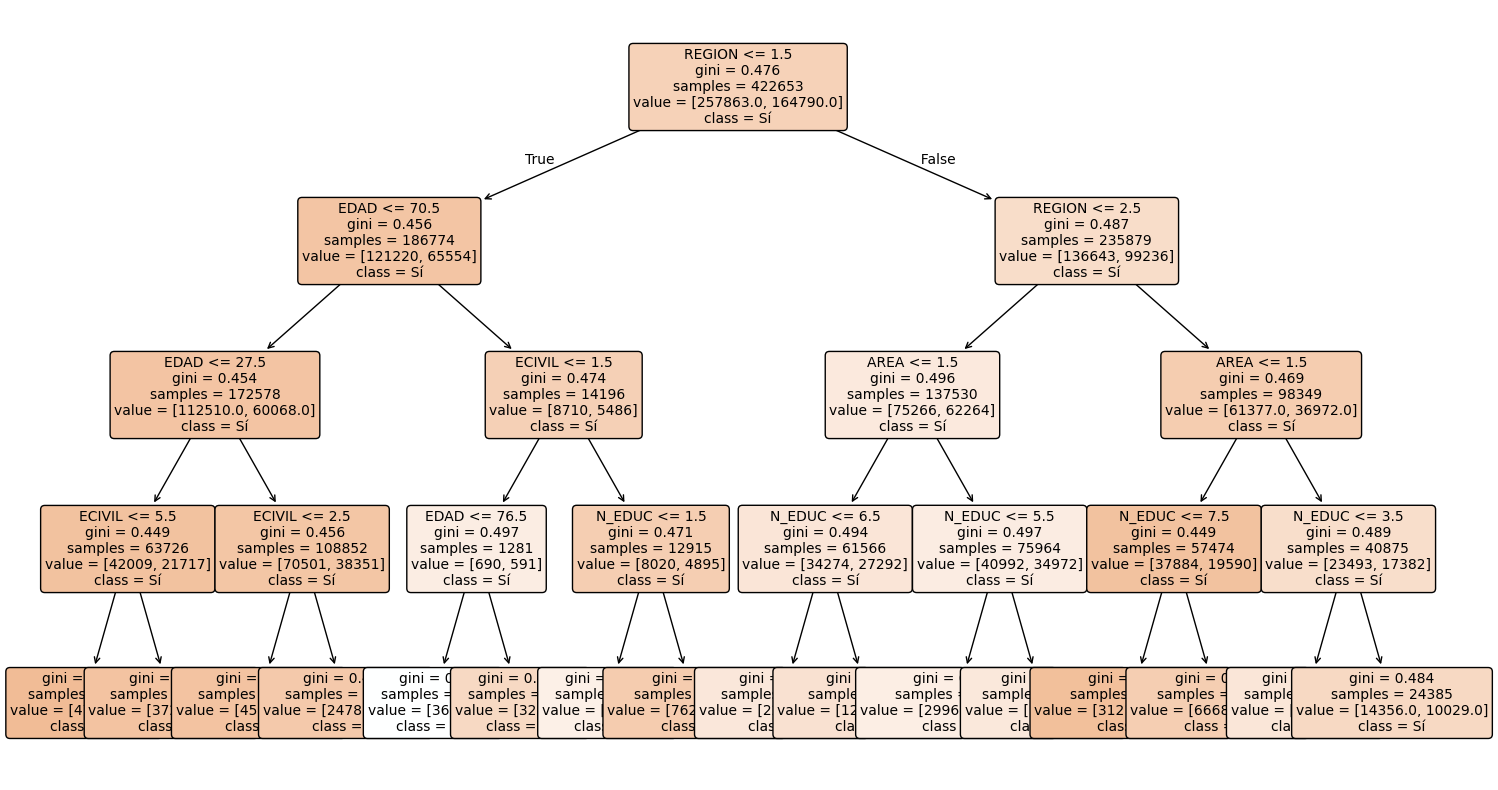

In [68]:
plt.figure(figsize=(18,10))
plot_tree(modelo, feature_names=X.columns,
    class_names=["Sí","No"],
    filled=True,
    rounded=True,
    fontsize=10)
plt.show()

In [69]:
# Importancia de variables
importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo.feature_importances_})
importancias.sort_values(by="Importancia",
    ascending=False)

,Variable,Importancia
5,REGION,0.757322
4,AREA,0.161375
3,N_EDUC,0.038309
1,EDAD,0.024429
2,ECIVIL,0.018566
0,SEXO,0.000000


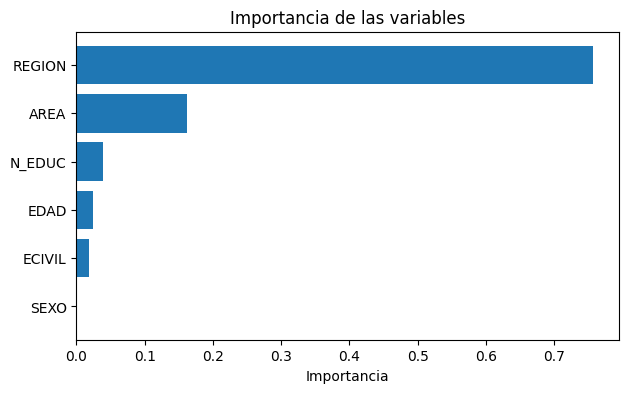

In [70]:
importancias = importancias.sort_values(by="Importancia", ascending=True)
plt.figure(figsize=(7,4))
plt.barh(importancias["Variable"], importancias["Importancia"])
plt.xlabel("Importancia")
plt.title("Importancia de las variables")
plt.show()

### **2.2 Random forest**

In [84]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [85]:
X = datos[["SEXO","EDAD","ECIVIL","N_EDUC","AREA","REGION"]]
y = datos["CAFE"]

In [86]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30,
                                                    random_state=123)

In [87]:
modelo = RandomForestClassifier(
    n_estimators=100,
    random_state=123)
modelo.fit(X_train, y_train)

RandomForestClassifier(random_state=123)

In [88]:
pred = modelo.predict(X_test)

In [89]:
accuracy = accuracy_score(y_test, pred)
print("Accuracy:", accuracy)

Accuracy: 0.5717905685168214


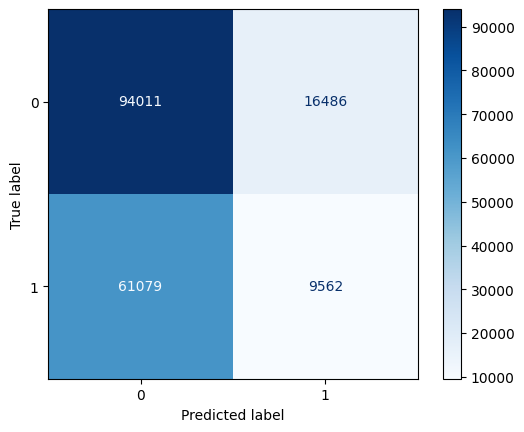

In [90]:
cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues")
plt.show()

In [91]:
importancia = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo.feature_importances_})
importancia.sort_values(
    by="Importancia",
    ascending=False)

,Variable,Importancia
1,EDAD,0.676058
3,N_EDUC,0.143161
5,REGION,0.074101
2,ECIVIL,0.067435
4,AREA,0.024514
0,SEXO,0.014731


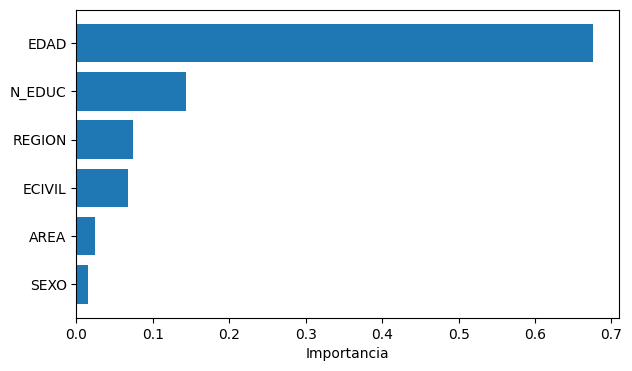

In [93]:
importancia = importancia.sort_values(by="Importancia", ascending=True)
plt.figure(figsize=(7,4))
plt.barh(importancia["Variable"],
    importancia["Importancia"])
plt.xlabel("Importancia")
plt.show()

In [94]:
# Predicción
nuevo = pd.DataFrame({
    "SEXO":[1],
    "EDAD":[35],
    "ECIVIL":[2],
    "N_EDUC":[3],
    "AREA":[1],
    "REGION":[2]})
modelo.predict(nuevo)

array([1.])

**El modelo predice que la persona consume café.**